In [1]:
import pandas as pd
import numpy as np
from src.common.utils import get_root_directory, collate_array_elements
import matplotlib.pyplot as plt
from src.preprocessing.data_loader import DataLoader
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import mlflow
import mlflow.sklearn
from xgboost import XGBRegressor
import shap

### Feature Selection

In [2]:
n_periods = 7
start_date = "01/01/2021"
end_date = "31/12/2023"
split_size = 0.15

In [3]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
publishers = ['Cointelegraph', 'CoinDesk', 'CoinGape', 'Cointelegraph Deutschland', 'U.Today','The Block', 'Decrypt', 'Cointelegraph Brasil', 'Blockworks','br.cointelegraph.com']
DL.merge_selected_data(selected_data=['BTC','LTC','sentiment_analysis'])
DL.final_data.columns

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Index(['ETH_D_AvgPrc', 'ETH_D_PrcDir', 'ETH_YF_Op', 'ETH_YF_Hi', 'ETH_YF_Lo',
       'ETH_YF_Cls', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
       'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
       'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
       'ETH_OL_MktCap', 'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol',
       'BTC_D_AvgPrc', 'BTC_YF_Op', 'BTC_YF_Hi', 'BTC_YF_Lo', 'BTC_YF_Cls',
       'BTC_YF_Vol', 'BTC_OL_MktCap', 'BTC_OL_BlkSz', 'BTC_OL_AvgComPwr',
       'BTC_OL_AvgTransFee', 'BTC_OL_MinDif', 'BTC_OL_ActAdd', 'BTC_OL_NewAdd',
       'BTC_OL_ChnTrans', 'BTC_OL_ChnVol', 'BTC_BIC_HshRt', 'LTC_D_AvgPrc',
       'LTC_YF_Op', 'LTC_YF_Hi', 'LTC_YF_Lo', 'LTC_YF_Cls', 'LTC_YF_Vol',
       'LTC_OL_MktCap', 'LTC_OL_BlkSz', 'LTC_OL_AvgComPwr',
       'LTC_OL_AvgTransFee', 'LTC_OL_MinDif', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd',
       'LTC_OL_ChnTrans', 'LTC_BIC_HshRt', 'D_VADER_AvgScr_In',
       'D_VADER_Sent_AvgIn', 'D_VADE

In [4]:
selected_features = ['ETH_D_AvgPrc','ETH_ES_GasUsd', 'ETH_ES_BlkSz','ETH_ES_AvgTransFee']
DL.select_features(features=selected_features)
lag_config = {col:5 for col in selected_features}
DL.lag_features(lag_config=lag_config)
DL.generate_forecast_horizon(horizon=n_periods)
DL.set_time_range(start_date=start_date, end_date=end_date)

In [5]:
train, test = DL.split_data(split_size=split_size)
# train, val = DL.split_data(split_type="train_val", split_size=split_size)
features = [col for col in train.columns if 'lag' in col]
targets = [col for col in train.columns if'horizon' in col]
y_train, x_train = train[targets], train[features]
# # y_val, x_val = val[targets], val[features]
# y_test, x_test = test[targets], test[features]

In [7]:
XGB = XGBRegressor(random_state=42, gamma=1, importance_type="gain")
XGB.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type='gain', interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [25]:
importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': XGB.feature_importances_
}).sort_values(by='Importance', ascending=False)
importance_df.head(30)

,Feature,Importance
0,ETH_D_AvgPrc_lag_1,1.0
1,ETH_D_AvgPrc_lag_2,0.0
18,ETH_ES_AvgTransFee_lag_4,0.0
17,ETH_ES_AvgTransFee_lag_3,0.0
16,ETH_ES_AvgTransFee_lag_2,0.0
15,ETH_ES_AvgTransFee_lag_1,0.0
14,ETH_ES_BlkSz_lag_5,0.0
13,ETH_ES_BlkSz_lag_4,0.0
12,ETH_ES_BlkSz_lag_3,0.0
11,ETH_ES_BlkSz_lag_2,0.0


In [26]:
print(sum(XGB.feature_importances_))

1.0


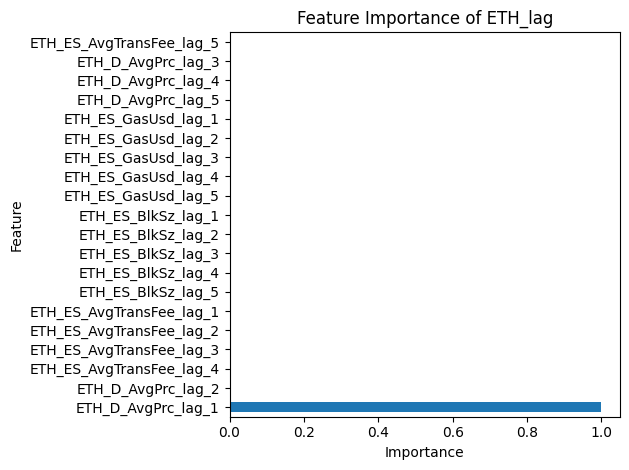

In [23]:
importance_df.plot(kind='barh', x='Feature', y='Importance', legend=False)
plt.title('Feature Importance of ETH_lag')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [8]:
explainer = shap.TreeExplainer(XGB, x_train)
shap_values = explainer(x_train)
# avg_explanation = shap.Explanation(
#     values=shap_values.values.mean(axis=2) ,
#     base_values=np.mean(shap_values.base_values, axis=1),  # shape: (931,)
#     data=shap_values.data,
#     feature_names=shap_values.feature_names
# )

100%|===================| 6512/6517 [03:35<00:00]        

In [20]:
shap_values.base_values.shape

(931, 7)

In [18]:
np.mean(shap_values.base_values, axis=1).shape

(931,)

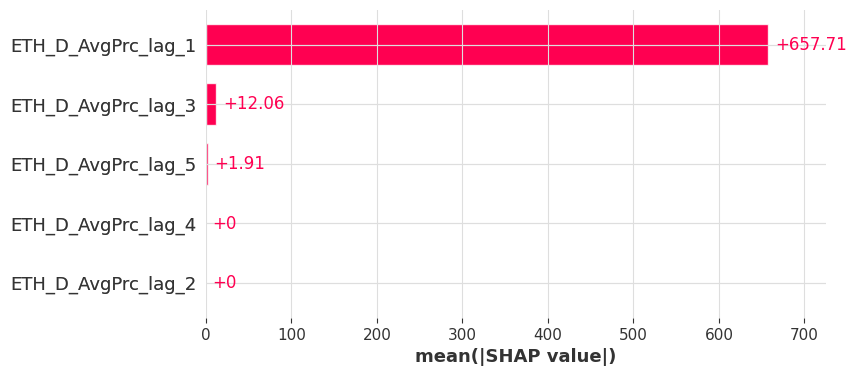

In [115]:
shap.plots.bar(shap_values=avg_explanation, max_display=100, show=False)
model = "XGB"
plt.savefig(f"{root_dir}\\reports\\figures\\feature_selection\\{model}\\ETH_lag.jpg", format="jpg", bbox_inches='tight', dpi=400)

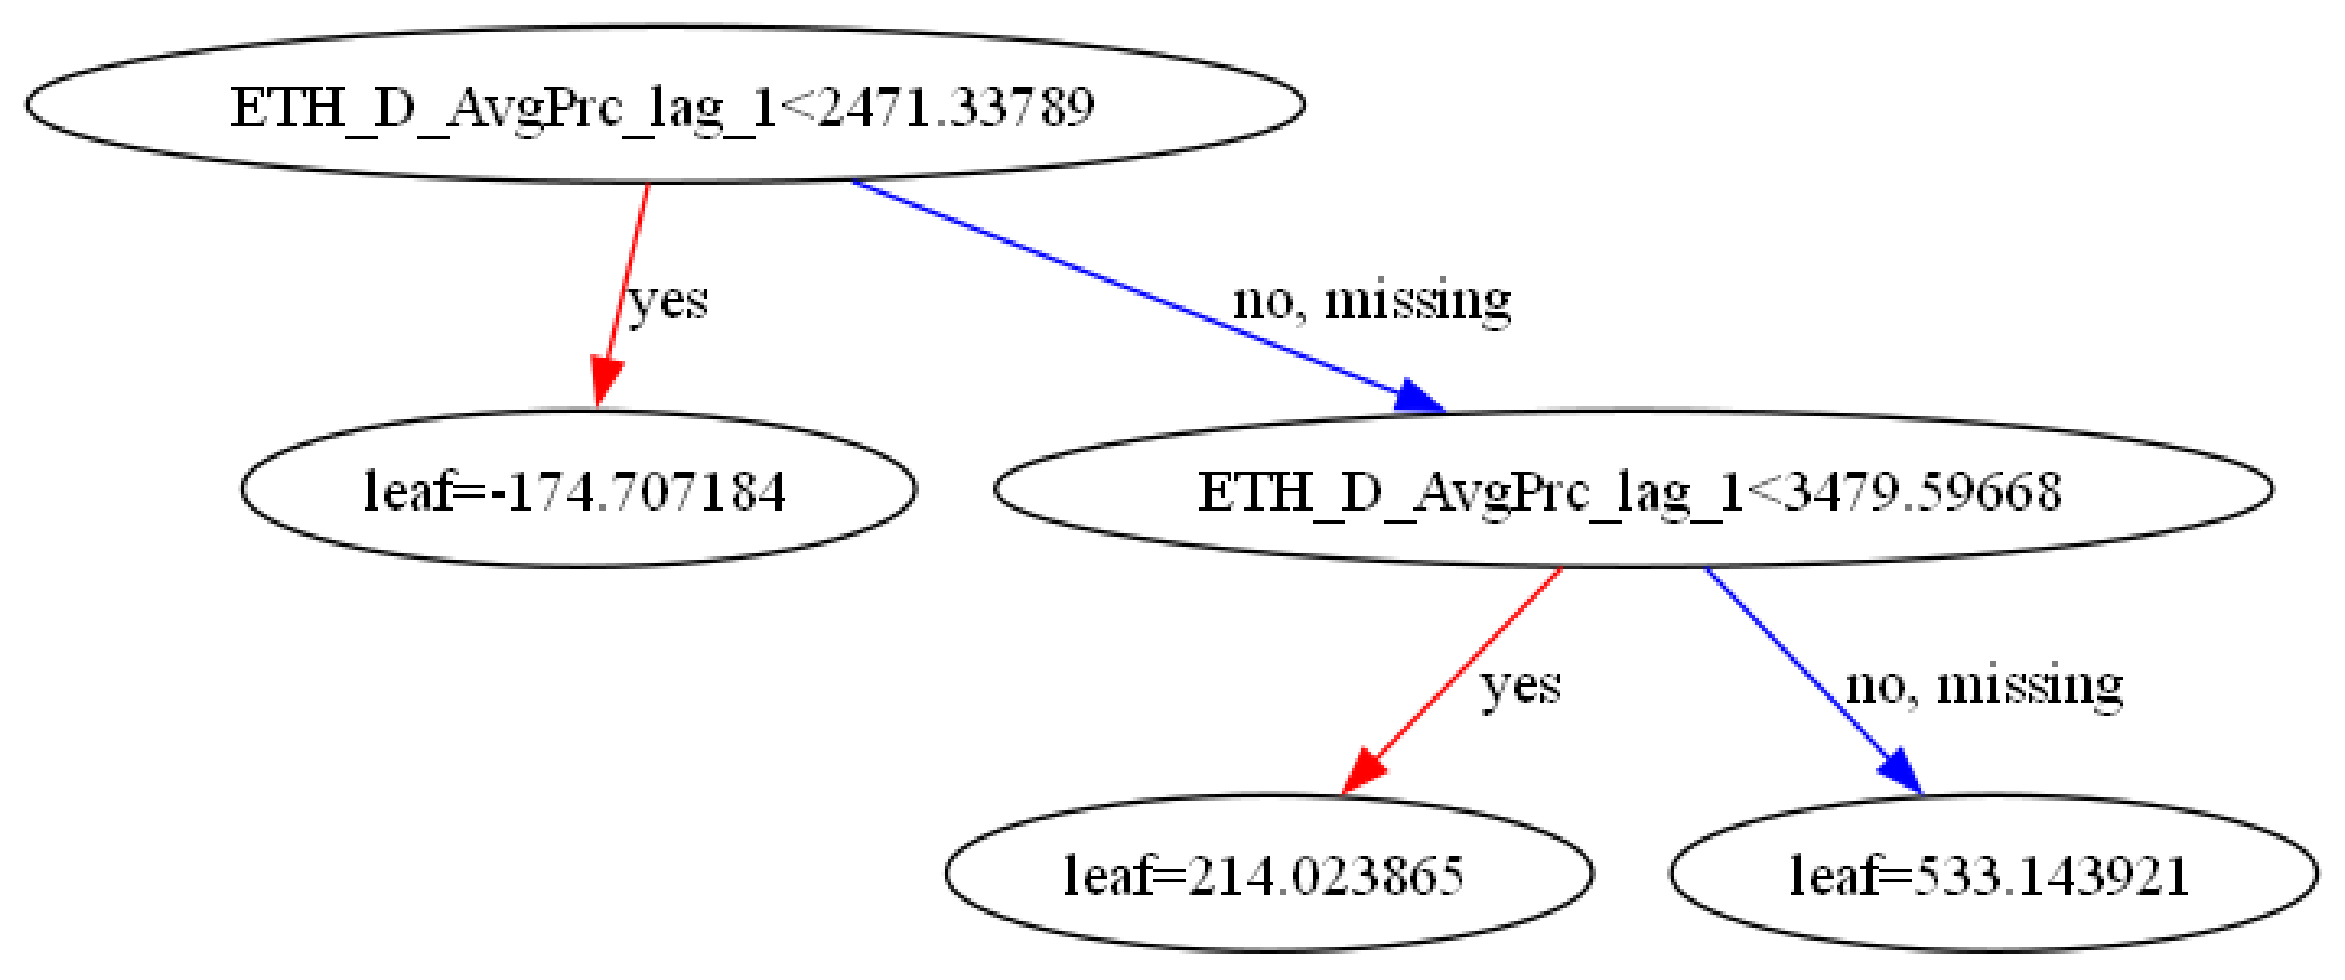

In [27]:
from xgboost import plot_tree
import matplotlib.pyplot as plt

plot_tree(XGB)
fig = plt.gcf()
fig.set_size_inches(30, 15)  # optional: resize
# plt.savefig("xgboost_tree_gamma_1_10000000_1.png", dpi=300, bbox_inches='tight')  # Save the figure
plt.show()

In [22]:
dump_list = XGB.get_booster().get_dump()
dump_list

['0:[ETH_D_AvgPrc_lag_1<2471.33789] yes=1,no=2,missing=2\n\t1:[ETH_D_AvgPrc_lag_1<1666.18713] yes=3,no=4,missing=4\n\t\t3:[ETH_D_AvgPrc_lag_1<1413.33521] yes=7,no=8,missing=8\n\t\t\t7:leaf=-301.847687\n\t\t\t8:leaf=-199.817291\n\t\t4:[ETH_D_AvgPrc_lag_1<2027.07568] yes=9,no=10,missing=10\n\t\t\t9:[ETH_D_AvgPrc_lag_1<1830.09924] yes=15,no=16,missing=16\n\t\t\t\t15:[ETH_D_AvgPrc_lag_1<1757.96313] yes=23,no=24,missing=24\n\t\t\t\t\t23:leaf=-157.981598\n\t\t\t\t\t24:leaf=-130.607437\n\t\t\t\t16:[ETH_D_AvgPrc_lag_1<1934.86584] yes=25,no=26,missing=26\n\t\t\t\t\t25:[ETH_ES_AvgTransFee_lag_2<2.38000011] yes=37,no=38,missing=38\n\t\t\t\t\t\t37:leaf=-30.6468391\n\t\t\t\t\t\t38:leaf=-109.335167\n\t\t\t\t\t26:[ETH_OL_ChnTrans_lag_2<1333863] yes=39,no=40,missing=40\n\t\t\t\t\t\t39:leaf=-84.1685715\n\t\t\t\t\t\t40:leaf=-34.3222923\n\t\t\t10:[ETH_D_AvgPrc_lag_1<2224.53223] yes=17,no=18,missing=18\n\t\t\t\t17:[ETH_OL_NewAdd_lag_1<230174] yes=27,no=28,missing=28\n\t\t\t\t\t27:[ETH_ES_AvgTransFee_lag_1

## ETH Blockchain Features

In [2]:
n_periods = 7
start_date = "01/01/2021"
end_date = "31/12/2023"
split_size = 0.15

In [3]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
publishers = ['Cointelegraph', 'CoinDesk', 'CoinGape', 'Cointelegraph Deutschland', 'U.Today','The Block', 'Decrypt', 'Cointelegraph Brasil', 'Blockworks','br.cointelegraph.com']
DL.merge_selected_data(selected_data=['BTC','LTC','sentiment_analysis'])

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

In [4]:
DL.final_data.columns

Index(['ETH_D_AvgPrc', 'ETH_D_PrcDir', 'ETH_YF_Op', 'ETH_YF_Hi', 'ETH_YF_Lo',
       'ETH_YF_Cls', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
       'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
       'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
       'ETH_OL_MktCap', 'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol',
       'BTC_D_AvgPrc', 'BTC_YF_Op', 'BTC_YF_Hi', 'BTC_YF_Lo', 'BTC_YF_Cls',
       'BTC_YF_Vol', 'BTC_OL_MktCap', 'BTC_OL_BlkSz', 'BTC_OL_AvgComPwr',
       'BTC_OL_AvgTransFee', 'BTC_OL_MinDif', 'BTC_OL_ActAdd', 'BTC_OL_NewAdd',
       'BTC_OL_ChnTrans', 'BTC_OL_ChnVol', 'BTC_BIC_HshRt', 'LTC_D_AvgPrc',
       'LTC_YF_Op', 'LTC_YF_Hi', 'LTC_YF_Lo', 'LTC_YF_Cls', 'LTC_YF_Vol',
       'LTC_OL_MktCap', 'LTC_OL_BlkSz', 'LTC_OL_AvgComPwr',
       'LTC_OL_AvgTransFee', 'LTC_OL_MinDif', 'LTC_OL_ActAdd', 'LTC_OL_NewAdd',
       'LTC_OL_ChnTrans', 'LTC_BIC_HshRt', 'D_VADER_AvgScr_In',
       'D_VADER_Sent_AvgIn', 'D_VADE

In [5]:
sent = 'D_CRYPTOBERT_AvgScr_Ex'
lag_config = {'ETH_D_AvgPrc':5}
DL.lag_features(lag_config=lag_config)
DL.generate_forecast_horizon(horizon=n_periods)
DL.set_time_range(start_date=start_date, end_date=end_date)
train, test = DL.split_data(split_size=split_size)
train, val = DL.split_data(split_type="train_val", split_size=split_size)
features = [col for col in train.columns if 'lag' in col]
targets = [col for col in train.columns if'horizon' in col]

Column ETH_D_PrcDir not found in lag_config, removing the column from the dataset.
Column ETH_YF_Op not found in lag_config, removing the column from the dataset.
Column ETH_YF_Hi not found in lag_config, removing the column from the dataset.
Column ETH_YF_Lo not found in lag_config, removing the column from the dataset.
Column ETH_YF_Cls not found in lag_config, removing the column from the dataset.
Column ETH_YF_Vol not found in lag_config, removing the column from the dataset.
Column ETH_ES_AvgTransFee not found in lag_config, removing the column from the dataset.
Column ETH_ES_AvgGasPrc not found in lag_config, removing the column from the dataset.
Column ETH_ES_BlkCnt not found in lag_config, removing the column from the dataset.
Column ETH_ES_BlkSz not found in lag_config, removing the column from the dataset.
Column ETH_ES_BlkTm not found in lag_config, removing the column from the dataset.
Column ETH_ES_ActAdd not found in lag_config, removing the column from the dataset.
Colum

In [6]:
train

,ETH_D_AvgPrc_horizon_0,ETH_D_AvgPrc_lag_1,ETH_D_AvgPrc_lag_2,ETH_D_AvgPrc_lag_3,ETH_D_AvgPrc_lag_4,ETH_D_AvgPrc_lag_5,ETH_D_AvgPrc_horizon_1,ETH_D_AvgPrc_horizon_2,ETH_D_AvgPrc_horizon_3,ETH_D_AvgPrc_horizon_4,ETH_D_AvgPrc_horizon_5,ETH_D_AvgPrc_horizon_6
Date,,,,,,,,,,,,
2021-01-01,734.267502,742.560349,739.595978,722.995285,710.671677,664.564499,752.461395,882.036545,1020.696609,1064.421906,1145.444794,1220.944794
2021-01-02,752.461395,734.267502,742.560349,739.595978,722.995285,710.671677,882.036545,1020.696609,1064.421906,1145.444794,1220.944794,1200.018524
2021-01-03,882.036545,752.461395,734.267502,742.560349,739.595978,722.995285,1020.696609,1064.421906,1145.444794,1220.944794,1200.018524,1247.739990
2021-01-04,1020.696609,882.036545,752.461395,734.267502,742.560349,739.595978,1064.421906,1145.444794,1220.944794,1200.018524,1247.739990,1271.439880
2021-01-05,1064.421906,1020.696609,882.036545,752.461395,734.267502,742.560349,1145.444794,1220.944794,1200.018524,1247.739990,1271.439880,1134.578461
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-27,1638.263428,1617.811188,1595.017517,1625.876862,1650.385040,1642.543213,1621.815369,1633.614105,1651.379883,1604.413055,1565.894012,1568.952759
2023-02-28,1621.815369,1638.263428,1617.811188,1595.017517,1625.876862,1650.385040,1633.614105,1651.379883,1604.413055,1565.894012,1568.952759,1567.150421
2023-03-01,1633.614105,1621.815369,1638.263428,1617.811188,1595.017517,1625.876862,1651.379883,1604.413055,1565.894012,1568.952759,1567.150421,1562.911896


## Expanding Windows

In [110]:
purpose = "feature_selection"
method = "manual"
split = "test"
experiment_name = f"XGB_{purpose}_{split}_{method}"
mlflow.set_tracking_uri(f"sqlite:///{root_dir}/mlruns/mlruns.db")
mlflow.set_experiment(experiment_name)
# gamma = 70000000
gamma_values = [70000000]
multi_strategy = "multi_output_tree"

for gamma in gamma_values:
    predictions = []
    y_train, x_train = train[targets].to_numpy(), train[features].to_numpy()
    y_val, x_val = val[targets].to_numpy(), val[features].to_numpy()
    y_test, x_test = test[targets].to_numpy(), test[features].to_numpy()
    y_train_gapped, x_train_gapped = y_train[:-n_periods], x_train[:-n_periods]
    y_val_gapped, x_val_gapped = y_val[:-n_periods], x_val[:-n_periods]
    y_test_gapped, x_test_gapped = y_test[:-n_periods], x_test[:-n_periods]
    with mlflow.start_run(run_name=f"ETH_lag"):
        mlflow.log_params({"lag_config":lag_config, "gamma":gamma, "multi_strategy":multi_strategy})
        XGB = XGBRegressor(random_state=42, gamma=gamma, multi_strategy=multi_strategy, n_estimators=500)
        if split.lower() == "validation":
            iter_array = y_val_gapped
            target_array = y_val
            feature_array = x_val_gapped
        elif split.lower() == "test":
            iter_array = y_test_gapped
            target_array = y_test
            feature_array = x_test_gapped
        for t in range(len(iter_array)):
            XGB.fit(x_train_gapped, y_train_gapped)
            forecast = XGB.predict(feature_array[t:t+1])
            predictions.append(forecast.flatten().tolist())
            y_train_gapped = np.vstack((y_train_gapped, y_train[-n_periods]))
            x_train_gapped = np.vstack((x_train_gapped, x_train[-n_periods]))
            y_train = np.vstack((y_train, target_array[t:t+1]))
            x_train = np.vstack((x_train, feature_array[t:t+1]))
        mse_list = []
        rmse_list = []
        mae_list = []
        mape_list = []
        transposed = collate_array_elements(predictions)
        for i in range(len(transposed)):
            mse = mean_squared_error(target_array[i:-n_periods+i,i], transposed[i])
            rmse = root_mean_squared_error(target_array[i:-n_periods+i,i], transposed[i])
            mae = mean_absolute_error(target_array[i:-n_periods+i,i], transposed[i])
            mape = mean_absolute_percentage_error(target_array[i:-n_periods+i,i], transposed[i])
            mse_list.append(mse)
            rmse_list.append(rmse)
            mae_list.append(mae)
            mape_list.append(mape)
            mlflow.log_metrics({"mse_daily":mse_list[i], "rmse_daily":rmse_list[i], "mae_daily":mae_list[i], "mape_daily":mape_list[i]}, step=(i+1))
        avg_mse = sum(mse_list)/len(mse_list)
        avg_rmse = sum(rmse_list)/len(rmse_list)
        avg_mae = sum(mae_list)/len(mae_list)
        avg_mape = sum(mape_list)/len(mape_list)
        mlflow.log_metrics({"avg_mse": avg_mse, "avg_rmse": avg_rmse, "avg_mae": avg_mae, "avg_mape": avg_mape})
    mlflow.end_run()